# Customer Segmentation & Churn Analysis — who are our customers, and who is about to leave?

**Author:** Fordrane Albert Okumu · **Tools:** Python (pandas, scikit-learn, statsmodels, matplotlib)
**Companion:** the same segmentation and churn model rebuilt in base R lives in [`R/segmentation_and_churn.R`](../R/segmentation_and_churn.R).

---

## 0. Why these two analyses belong together

An FMCG distributor in Kenya sells to about 4,000 **outlets**: dukas, supermarkets, wholesalers, hotels & restaurants (HoReCa) and petrol-station shops. Two questions decide where the sales team spends its time:

1. **Segmentation:** *who are our customers?* Not every outlet is worth the same, and not every outlet needs the same service. Segmentation groups outlets with similar buying behaviour so each group can get a fitting strategy: protect, grow, win back or serve at low cost.
2. **Churn analysis:** *who is about to stop buying, and why?* Winning a new outlet usually costs far more than keeping an existing one. A churn model flags at-risk outlets **before** they go silent, while there's still time to act.

Put together, they answer the question that matters commercially: ***which valuable customers are we about to lose, and what should we do about it?***

### The data

The data is **synthetic**. It was generated by [`data/generate_data.py`](../data/generate_data.py) to look like a real B2B distribution business: 4,000 outlets, about 180,000 orders and about 14,000 complaints from January 2025 to September 2026. Hidden drivers (price sensitivity, service quality, competition) affect each outlet's behaviour, but, as in real life, **only observable data is exported**: orders, deliveries, complaints and outlet attributes. No real company or customer data is used.

| File | One row per | Key columns |
|---|---|---|
| `customers.csv` | outlet | channel, region, onboarding month, has merchandiser, credit terms |
| `orders.csv` | order | date, net value (KES), SKUs, discount %, late delivery, stock-out, returns |
| `complaints.csv` | complaint | date, type (late delivery, stock-out, pricing, quality) |

## 1. Setup

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, roc_auc_score, roc_curve, average_precision_score,
                             brier_score_loss, confusion_matrix, precision_score, recall_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

ROOT = Path.cwd().parent if Path.cwd().name == "python" else Path.cwd()
sys.path.insert(0, str(ROOT / "python"))
from features import load, build_features, churn_label, is_test, CUTOFF, HORIZON_DAYS

OUT = ROOT / "outputs" / "python"; OUT.mkdir(parents=True, exist_ok=True)
TEAL, AMBER, GREY, RED = "#0f766e", "#b45309", "#94a3b8", "#b91c1c"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
pd.set_option("display.width", 170, "display.max_columns", 30)
kes = lambda x: f"KES {x/1e6:,.1f}m"

## 2. Load and check the data

In [2]:
cust, orders, complaints = load()
print(f"{len(cust):,} outlets | {len(orders):,} orders | {len(complaints):,} complaints | "
      f"{orders.order_date.min():%b %Y} - {orders.order_date.max():%b %Y}")
quality = pd.Series({
    "missing values (orders)": int(orders.isna().sum().sum()),
    "duplicate order_ids": int(orders.order_id.duplicated().sum()),
    "orders with value <= 0": int((orders.net_value_kes <= 0).sum()),
    "orders from unknown outlets": int((~orders.customer_id.isin(cust.customer_id)).sum()),
}, name="count")
display(quality.to_frame())
display(cust.channel.value_counts().rename("outlets").to_frame().assign(share=lambda d: (d.outlets / d.outlets.sum()).round(3)))

4,000 outlets | 179,565 orders | 13,758 complaints | Jan 2025 - Sep 2026


,count
missing values (orders),0
duplicate order_ids,0
orders with value <= 0,0
orders from unknown outlets,0


,outlets,share
channel,,
Duka,1916,0.479
HoReCa,712,0.178
Petrol Station,485,0.121
Supermarket,483,0.121
Wholesaler,404,0.101


**Interpretation:** the data passes all quality checks. Dukas make up nearly half the outlets but, as we'll see, a small share of revenue. That imbalance is the first hint that segmentation is needed.

## 3. The single most important design decision: avoid data leakage

A churn model has to predict the **future** using only the **past**. If information from *after* the prediction date leaks into the features, the model looks brilliant in testing and fails in production.

We take a **snapshot** on **30 June 2026**:

```
 Jan 2025 ───────────── OBSERVATION WINDOW ────────────── 30 Jun 2026 ──── OUTCOME WINDOW (90 days) ──── 28 Sep 2026
        features are computed only from here                │        label: did the outlet order again?
                                                         snapshot
```

* **Features** (recency, frequency, value, service experience…) use only orders and complaints **up to 30 June 2026**.
* **Churn label** = 1 if an outlet that was *active* at the snapshot (ordered in the last 90 days) places **no order in the next 90 days**.
* In production you'd run the same code every month with a new snapshot date and score every active outlet.

## 4. Feature engineering — turning orders into customer behaviour

Each feature captures one aspect of the relationship:

| Feature | Definition | Why it matters |
|---|---|---|
| `recency_days` | Days since last order | The single strongest sign of disengagement |
| `frequency_365d` | Orders in the last 12 months | Habit strength |
| `monetary_365d` | Net sales in the last 12 months (KES) | Value of the customer |
| `avg_order_value` | Average order size | Outlet size / wallet |
| `avg_skus_per_order` | Range breadth | Outlets that stock more of our range are more embedded |
| `order_trend` | Orders in last 90 days ÷ average 90-day orders in the prior 270 days | **Fading**: < 1 means slowing down |
| `avg_discount_pct` | Average discount received | Price sensitivity |
| `late_delivery_rate`, `stockout_rate` | Share of orders delivered late / short | Service failures |
| `return_rate` | Returned value ÷ net sales | Quality or over-supply problems |
| `complaints_180d` | Complaints in the last 6 months | Voice of the customer |
| `tenure_months` | Months since first order | New customers churn more |
| `has_merchandiser`, `channel`, `region` | Attributes | Relationship model and market |

In [3]:
F = build_features(cust, orders, complaints)
print(f"Feature table: {F.shape[0]:,} outlets x {F.shape[1]} columns (outlets with at least one order before the snapshot)")
F.describe().T[["mean", "50%", "min", "max"]].round(2)

Feature table: 3,976 outlets x 20 columns (outlets with at least one order before the snapshot)


,mean,50%,min,max
recency_days,143.22,34.00,3.00,545.00
frequency_365d,25.44,19.00,0.00,269.00
monetary_365d,1978889.05,236158.50,0.00,97142916.00
orders_90d,5.72,3.00,0.00,68.00
orders_prior_270d,19.72,15.00,0.00,201.00
order_trend,0.96,0.94,0.04,10.20
avg_order_value,46149.47,17145.00,1811.50,529304.00
avg_skus_per_order,3.78,3.18,1.00,10.00
avg_discount_pct,0.05,0.04,0.00,0.11
late_delivery_rate,0.13,0.12,0.00,1.00


---
# PART A — CUSTOMER SEGMENTATION

We segment every outlet that ordered at least once in the 12 months before the snapshot, including those that have since gone quiet, because "lost" customers are a segment too. We use two complementary methods:

1. **RFM segmentation:** a transparent, rule-based business standard.
2. **K-means clustering:** a data-driven method that can find groups no one thought to define.

## 5. RFM segmentation

**RFM** scores each customer on three dimensions, from 1 (worst) to 5 (best), using quintiles:

* **R**ecency: recently active scores 5
* **F**requency: orders often scores 5
* **M**onetary: spends the most scores 5

The scores are then mapped to named segments that any sales manager understands immediately. Quintile scoring is *relative*: a "5" means top 20% of this customer base.

In [4]:
S = F[F.frequency_365d > 0].copy()
S["R"] = pd.qcut(S.recency_days.rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)   # low recency = good
S["F"] = pd.qcut(S.frequency_365d.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
S["M"] = pd.qcut(S.monetary_365d.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
S["FM"] = ((S.F + S.M) / 2).round().astype(int)

def rfm_segment(r, fm):
    if r >= 4 and fm >= 4: return "Champions"
    if r >= 3 and fm >= 3: return "Loyal"
    if r >= 4 and fm <= 2: return "Promising / New"
    if r == 3 and fm <= 2: return "Needs Attention"
    if r <= 2 and fm >= 4: return "Can't Lose Them"
    if r <= 2 and fm == 3: return "At Risk"
    return "Hibernating / Lost"

S["rfm_segment"] = [rfm_segment(r, fm) for r, fm in zip(S.R, S.FM)]
order = ["Champions", "Loyal", "Promising / New", "Needs Attention", "At Risk", "Can't Lose Them", "Hibernating / Lost"]
rfm = (S.groupby("rfm_segment").agg(outlets=("customer_id", "size"), median_recency=("recency_days", "median"),
                                    median_orders=("frequency_365d", "median"), revenue=("monetary_365d", "sum"))
         .reindex(order))
rfm["outlet_share"] = rfm.outlets / rfm.outlets.sum()
rfm["revenue_share"] = rfm.revenue / rfm.revenue.sum()
rfm.assign(revenue=rfm.revenue.map(kes)).round(3)

,outlets,median_recency,median_orders,revenue,outlet_share,revenue_share
rfm_segment,,,,,,
Champions,948,5.0,49.0,"KES 5,525.4m",0.288,0.702
Loyal,540,14.0,32.0,"KES 1,309.6m",0.164,0.166
Promising / New,245,6.0,18.0,KES 39.8m,0.074,0.005
Needs Attention,240,17.0,17.0,KES 34.6m,0.073,0.004
At Risk,141,126.0,21.0,KES 102.5m,0.043,0.013
Can't Lose Them,189,109.0,33.0,KES 724.7m,0.057,0.092
Hibernating / Lost,986,220.0,7.0,KES 131.4m,0.300,0.017


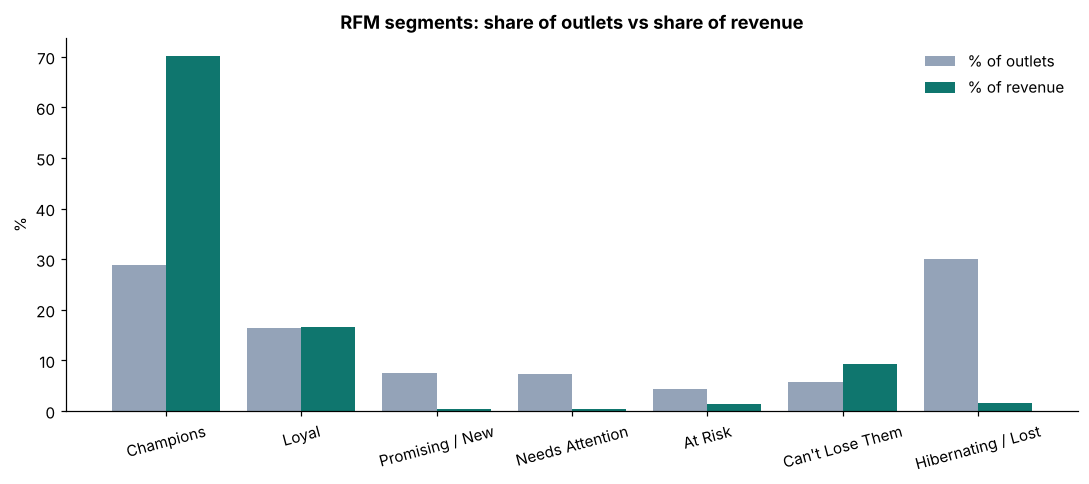

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(rfm))
ax.bar(x - .2, rfm.outlet_share * 100, .4, color=GREY, label="% of outlets")
ax.bar(x + .2, rfm.revenue_share * 100, .4, color=TEAL, label="% of revenue")
ax.set_xticks(x, rfm.index, rotation=15)
ax.set(ylabel="%", title="RFM segments: share of outlets vs share of revenue")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "01_rfm_segments.png", dpi=150); plt.show()

**Interpretation:**

* **Champions** are a minority of outlets but bring in the majority of revenue. This is the classic **Pareto pattern** of B2B distribution. They need *protection*: priority delivery, a dedicated rep, stock guarantees.
* **Can't Lose Them** are high-value outlets that *used to* buy a lot but haven't ordered recently. Each one is worth far more than a typical outlet, so they are the **first call for a win-back campaign**.
* **Hibernating / Lost** is a large group of outlets that bring in little revenue. They should get low-cost re-activation (SMS offers, telesales), not expensive field visits.
* **Promising / New** outlets are active but small. Range-expansion offers can grow them into Loyal customers.

## 6. K-means clustering — letting the data define the segments

RFM uses only three dimensions and fixed cut-offs. **K-means** can use more behaviour (order size, range breadth, trend, discount dependence) and finds the natural groupings.

### Preparing the data

* **Log-transform** skewed variables (recency, frequency, order value). Otherwise a few huge wholesalers dominate the distance calculation.
* **Standardise** every feature to mean 0, SD 1, so each one counts equally.

In [6]:
cluster_features = pd.DataFrame({
    "log_recency": np.log1p(S.recency_days), "log_frequency": np.log1p(S.frequency_365d),
    "log_order_value": np.log1p(S.avg_order_value), "skus_per_order": S.avg_skus_per_order,
    "log_order_trend": np.log(S.order_trend), "discount_pct": S.avg_discount_pct}, index=S.index)
Zs = StandardScaler().fit_transform(cluster_features)
cluster_features.describe().round(2)

,log_recency,log_frequency,log_order_value,skus_per_order,log_order_trend,discount_pct
count,3289.00,3289.00,3289.00,3289.00,3289.00,3289.00
mean,3.33,3.09,10.03,3.78,-0.38,0.05
std,1.51,0.95,1.14,1.41,0.86,0.01
min,1.39,0.69,7.50,1.00,-3.33,0.00
25%,2.08,2.56,9.13,2.87,-0.85,0.03
50%,2.83,3.22,9.75,3.18,-0.23,0.04
75%,4.87,3.76,10.89,5.00,0.16,0.06
max,5.90,5.60,13.18,10.00,2.32,0.11


### How many clusters? Elbow and silhouette

* **Elbow (inertia):** the within-cluster sum of squares always falls as *k* grows. We look for the point where extra clusters stop helping much.
* **Silhouette score** (−1 to 1): how well each customer fits its own cluster compared with the nearest other cluster. Higher is better.

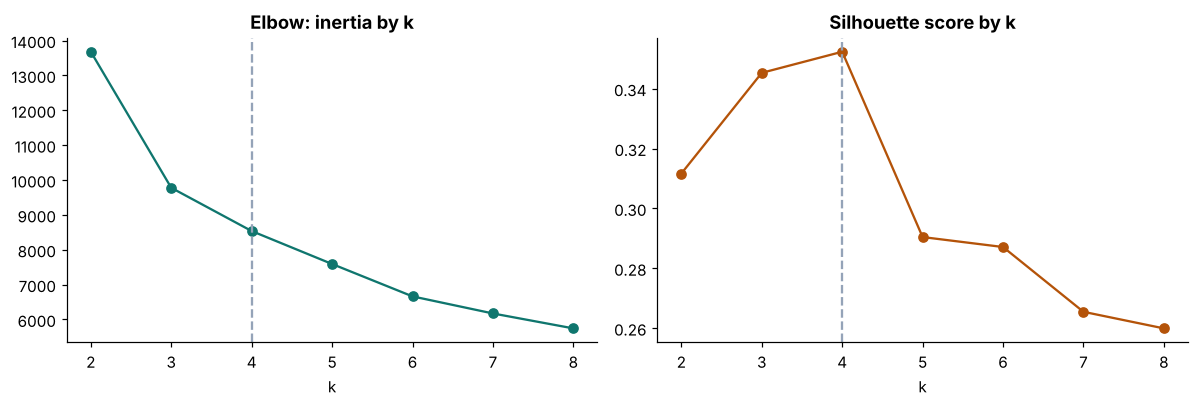

Best silhouette at k = 4


,inertia,silhouette
2,13679.333,0.312
3,9777.168,0.345
4,8536.494,0.352
5,7591.073,0.290
6,6662.422,0.287
7,6172.484,0.265
8,5744.237,0.260


In [7]:
ks = range(2, 9)
fits = {k: KMeans(k, n_init=20, random_state=42).fit(Zs) for k in ks}
sel = pd.DataFrame({"inertia": [fits[k].inertia_ for k in ks],
                    "silhouette": [silhouette_score(Zs, fits[k].labels_) for k in ks]}, index=ks)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(sel.index, sel.inertia, "o-", color=TEAL); ax[0].set(title="Elbow: inertia by k", xlabel="k")
ax[1].plot(sel.index, sel.silhouette, "o-", color=AMBER); ax[1].set(title="Silhouette score by k", xlabel="k")
best_k = int(sel.silhouette.idxmax())
for a in ax: a.axvline(best_k, ls="--", color=GREY)
fig.tight_layout(); fig.savefig(OUT / "02_choose_k.png", dpi=150); plt.show()
print(f"Best silhouette at k = {best_k}"); sel.round(3)

**Interpretation:** the silhouette score peaks at **k = 4** (0.35). The elbow curve gives its biggest gains up to k = 3–4 and flattens after that. Four clusters is the statistically best choice, and it's small enough for a sales team to act on.

In [8]:
km = fits[best_k]
S["cluster_id"] = km.labels_
prof = S.groupby("cluster_id").agg(outlets=("customer_id", "size"), median_recency=("recency_days", "median"),
                                   median_orders_12m=("frequency_365d", "median"),
                                   median_order_value=("avg_order_value", "median"),
                                   skus_per_order=("avg_skus_per_order", "mean"),
                                   median_trend=("order_trend", "median"), revenue=("monetary_365d", "sum"))
prof["revenue_share"] = prof.revenue / prof.revenue.sum()

# Name clusters from their profile (robust to K-means label order)
big = prof.median_order_value > S.avg_order_value.median()
active = prof.median_recency <= 60
prof["segment"] = np.select([big & active, ~big & active, big & ~active, ~big & ~active],
                            ["Key Accounts", "Core Small Outlets", "Lapsing Key Accounts", "Lapsed Small Outlets"], default="Other")
S["cluster"] = S.cluster_id.map(prof.segment)
prof = prof.set_index("segment").sort_values("revenue", ascending=False)
prof.assign(revenue=prof.revenue.map(kes)).round(2)

,outlets,median_recency,median_orders_12m,median_order_value,skus_per_order,median_trend,revenue,revenue_share
segment,,,,,,,,
Key Accounts,650,6.0,55.5,112351.96,5.98,1.02,"KES 5,962.4m",0.76
Core Small Outlets,1503,10.0,28.0,12912.31,3.05,1.05,"KES 1,027.6m",0.13
Lapsing Key Accounts,227,172.0,21.0,94309.40,5.46,0.15,KES 742.2m,0.09
Lapsed Small Outlets,909,220.0,8.0,11015.33,3.00,0.33,KES 135.9m,0.02


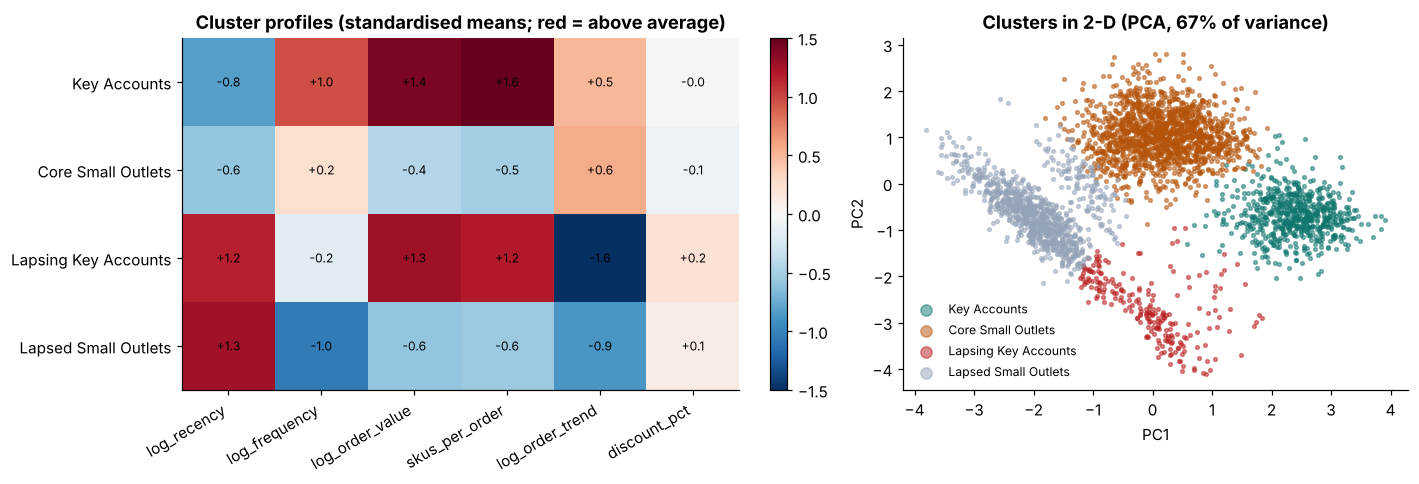

channel,Duka,HoReCa,Petrol Station,Supermarket,Wholesaler
segment,,,,,
Key Accounts,0.00,0.01,0.00,0.56,0.43
Core Small Outlets,0.59,0.24,0.17,0.00,0.00
Lapsing Key Accounts,0.02,0.18,0.04,0.37,0.40
Lapsed Small Outlets,0.66,0.19,0.14,0.00,0.00


In [9]:
z = pd.DataFrame(Zs, columns=cluster_features.columns, index=S.index).groupby(S.cluster).mean().loc[prof.index]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.2, 1]})
im = ax[0].imshow(z.values, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
ax[0].set_xticks(range(z.shape[1]), z.columns, rotation=30, ha="right"); ax[0].set_yticks(range(len(z)), z.index)
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        ax[0].text(j, i, f"{z.values[i, j]:+.1f}", ha="center", va="center", fontsize=8)
ax[0].set_title("Cluster profiles (standardised means; red = above average)")
plt.colorbar(im, ax=ax[0], fraction=.03)

pcs = PCA(2, random_state=0).fit(Zs)
P = pcs.transform(Zs)
colours = dict(zip(prof.index, [TEAL, AMBER, RED, GREY]))
for name, c in colours.items():
    m = (S.cluster == name).values
    ax[1].scatter(P[m, 0], P[m, 1], s=6, alpha=.5, color=c, label=name)
ax[1].set(title=f"Clusters in 2-D (PCA, {pcs.explained_variance_ratio_.sum():.0%} of variance)", xlabel="PC1", ylabel="PC2")
ax[1].legend(frameon=False, markerscale=3, fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "03_cluster_profiles.png", dpi=150); plt.show()

pd.crosstab(S.cluster, S.channel, normalize="index").loc[prof.index].round(2)

**Interpretation, the four behavioural segments:**

| Segment | What the data says | Strategy |
|---|---|---|
| **Key Accounts** | Supermarkets and wholesalers that order often, in large baskets, across a broad range. A minority of outlets, about three-quarters of revenue. | **Protect**: key-account management, service-level guarantees, joint business plans |
| **Core Small Outlets** | Dukas, HoReCa and petrol stations ordering steadily in small baskets | **Serve efficiently & grow**: route-optimised van sales, range-extension bundles |
| **Lapsing Key Accounts** | Big-basket outlets whose order trend has *collapsed* and who haven't ordered for months | **Win back now**: senior-rep visit, find the service failure, a tailored offer |
| **Lapsed Small Outlets** | Small outlets that have stopped ordering | **Low-cost re-activation**: SMS / telesales offers; accept some losses |

K-means found the same split a seasoned commercial manager would draw, **big vs small × active vs fading**, using only purchase behaviour. The heatmap shows *why*: order value and SKU breadth separate big from small, while recency and trend separate active from lapsing.

In [10]:
ct = pd.crosstab(S.rfm_segment, S.cluster).reindex(order)[prof.index]
ct

cluster,Key Accounts,Core Small Outlets,Lapsing Key Accounts,Lapsed Small Outlets
rfm_segment,,,,
Champions,478,470,0,0
Loyal,162,376,2,0
Promising / New,1,244,0,0
Needs Attention,1,237,0,2
At Risk,3,25,42,71
Can't Lose Them,5,24,127,33
Hibernating / Lost,0,127,56,803


**RFM vs K-means:** the two methods largely agree. Champions and Loyal sit mostly in Key Accounts and Core Small Outlets, and Hibernating / Lost sits mostly in the two lapsed clusters. They also add to each other: RFM gives a fine-grained, explainable ranking, while K-means adds *order size* and *trend*, which separate a fading supermarket from a fading duka. In practice: **K-means to design the strategy, RFM to prioritise individual outlets inside it.**

---
# PART B — CHURN ANALYSIS

## 7. Define churn and measure it

**Population:** outlets *active* at the snapshot (ordered in the 90 days before 30 June 2026).
**Churn = 1** if the outlet places **no order** in the next 90 days.

Why 90 days? Most active outlets order several times a month, so three silent months is a reliable sign the relationship has broken. A shorter window would flag seasonal pauses, and a longer one would detect churn too late to act.

In [11]:
A = F[F.recency_days <= 90].copy()
A["churned"] = churn_label(orders)(A.customer_id)
A = A.merge(S[["customer_id", "rfm_segment", "cluster"]], on="customer_id", how="left")
print(f"Active outlets at snapshot: {len(A):,} | churned in next {HORIZON_DAYS} days: {A.churned.sum()} "
      f"({A.churned.mean():.1%}) | revenue of churners (last 12m): {kes(A.loc[A.churned == 1, 'monetary_365d'].sum())}")

Active outlets at snapshot: 2,322 | churned in next 90 days: 252 (10.9%) | revenue of churners (last 12m): KES 499.6m


**Interpretation:** about **one in nine** active outlets stops buying within a quarter. The positive class is the *minority*, so plain accuracy would be misleading: a model that predicts "nobody churns" would be about 89% accurate and completely useless. We evaluate with **AUC, precision/recall and lift** instead.

## 8. Exploratory analysis — what do churners look like?

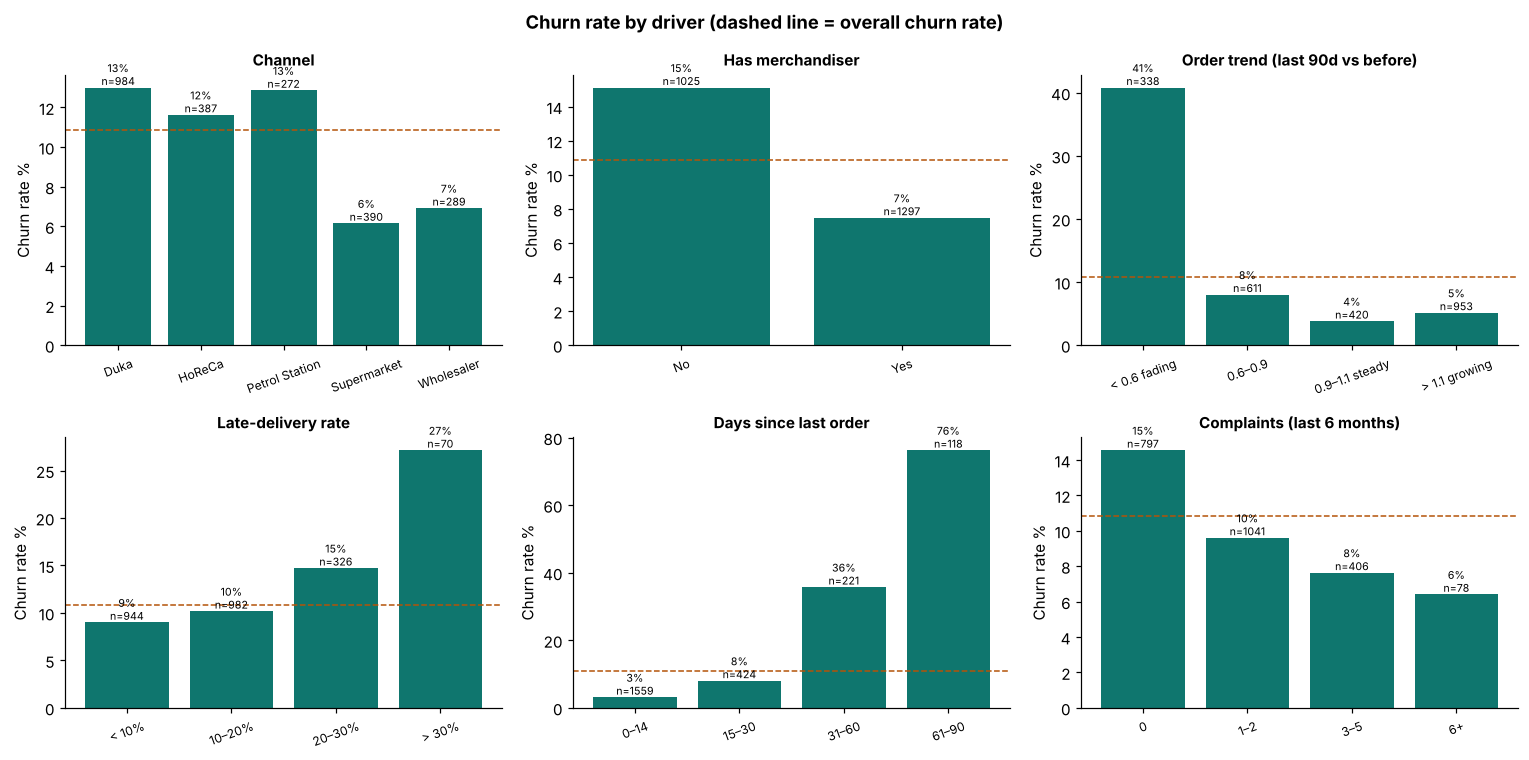

In [12]:
def rate_by(col, bins=None, labels=None):
    g = pd.cut(A[col], bins, labels=labels) if bins is not None else A[col]
    return A.groupby(g, observed=True).churned.agg(["mean", "size"]).rename(columns={"mean": "churn_rate", "size": "outlets"})

panels = {
    "Channel": rate_by("channel"),
    "Has merchandiser": rate_by("has_merchandiser").rename(index={0: "No", 1: "Yes"}),
    "Order trend (last 90d vs before)": rate_by("order_trend", [0, .6, .9, 1.1, 99], ["< 0.6 fading", "0.6–0.9", "0.9–1.1 steady", "> 1.1 growing"]),
    "Late-delivery rate": rate_by("late_delivery_rate", [-.01, .1, .2, .3, 1], ["< 10%", "10–20%", "20–30%", "> 30%"]),
    "Days since last order": rate_by("recency_days", [-1, 14, 30, 60, 90], ["0–14", "15–30", "31–60", "61–90"]),
    "Complaints (last 6 months)": rate_by("complaints_180d", [-1, 0, 2, 5, 99], ["0", "1–2", "3–5", "6+"]),
}
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (title, t) in zip(axes.flat, panels.items()):
    ax.bar(t.index.astype(str), t.churn_rate * 100, color=TEAL)
    ax.axhline(A.churned.mean() * 100, ls="--", color=AMBER, lw=1)
    ax.set_title(title, fontsize=10); ax.set_ylabel("Churn rate %"); ax.tick_params(axis="x", rotation=20, labelsize=8)
    for i, (r, n_) in enumerate(zip(t.churn_rate, t.outlets)):
        ax.text(i, r * 100, f"{r:.0%}\nn={n_}", ha="center", va="bottom", fontsize=7)
fig.suptitle("Churn rate by driver (dashed line = overall churn rate)", fontweight="bold")
fig.tight_layout(); fig.savefig(OUT / "04_churn_drivers_eda.png", dpi=150); plt.show()

**Interpretation:** each panel compares churn rates between groups:

* **Order trend** is the clearest early-warning signal. Outlets whose recent ordering fell **below 60% of their usual rate** churn at about **41%**, against about 4–8% for steady or growing outlets. Churn is a *fade*, not a sudden stop, which is exactly why it can be predicted.
* **Recency:** churn rises from about **3%** for outlets that ordered in the last two weeks to about **76%** for those silent for 61–90 days before the snapshot.
* **Channel:** dukas, HoReCa and petrol stations churn at about 12–13%, about twice the rate of supermarkets and wholesalers (6–7%). Small outlets have low switching costs and many competing distributors.
* **Merchandiser coverage:** outlets with a merchandiser churn at about **7.5%**, half the rate of those without (about 15%).
* **Late deliveries:** churn climbs from about 9% for outlets with under 10% late deliveries to about **27%** for outlets where more than 30% of orders arrive late. This is a **controllable** driver.
* **Complaints: a lesson in exposure bias.** Churn *falls* as complaints rise. That isn't because complaints are good. Busy outlets place more orders, so they have more chances to experience and report a problem, while quiet outlets that are drifting away barely complain at all. Raw counts mix up *activity* and *dissatisfaction*. A better feature is complaints **per order**, and silence can be a stronger warning sign than a complaint.

These are *univariate* views, and the drivers overlap (dukas also get fewer merchandiser visits, for example). The model in the next step separates each driver's **independent** effect.

## 9. Prepare the modelling data

* **Features:** the behavioural, service and attribute variables from section 4. `monetary_365d` is left out because it is almost exactly frequency × order value, which would create collinearity. `credit_terms_days` is left out because it is fully determined by channel.
* **Encoding:** channel and region become dummy variables. *Duka* and *Central* are the reference categories.
* **Split:** a deterministic **75 / 25 train / test split** (outlets whose ID number is divisible by 4 go to test). The R script uses the identical split, so results can be compared exactly.
* **Scaling:** numeric features are standardised using **training-set** means and SDs only (applying the training scaling to the test set avoids another, subtle form of leakage).

In [13]:
NUM = ["recency_days", "frequency_365d", "order_trend", "avg_order_value", "avg_skus_per_order",
       "avg_discount_pct", "late_delivery_rate", "stockout_rate", "return_rate", "complaints_180d",
       "tenure_months", "has_merchandiser"]
A["log_avg_order_value"] = np.log1p(A.avg_order_value)
A["log_order_trend"] = np.log(A.order_trend)
NUM = [c if c not in ("avg_order_value", "order_trend") else f"log_{c}" for c in NUM]
X = pd.get_dummies(A[NUM + ["channel", "region"]], columns=["channel", "region"], dtype=float)
X = X.drop(columns=["channel_Duka", "region_Central"])
y = A.churned.values
test = is_test(A.customer_id).values
mu, sd = X[~test].mean(), X[~test].std()
Xs = (X - mu) / sd
print(f"Train: {(~test).sum():,} outlets ({y[~test].mean():.1%} churn) | Test: {test.sum():,} outlets ({y[test].mean():.1%} churn) | "
      f"{X.shape[1]} features")

Train: 1,750 outlets (10.6% churn) | Test: 572 outlets (11.7% churn) | 21 features


## 10. Model 1 — Logistic regression (the explainable baseline)

Logistic regression models the **log-odds** of churn as a weighted sum of the features. Because the features are standardised, each coefficient shows the effect of a **one-standard-deviation** change. Exponentiating a coefficient gives an **odds ratio**:

* **OR > 1:** raises churn risk (e.g. OR 1.5 means 50% higher odds per 1 SD)
* **OR < 1:** protective

We fit it with `statsmodels` to get standard errors, confidence intervals and p-values.

In [14]:
logit = sm.Logit(y[~test], sm.add_constant(Xs[~test])).fit(disp=0)
ors = pd.DataFrame({"coef": logit.params, "odds_ratio": np.exp(logit.params),
                    "ci_low": np.exp(logit.conf_int()[0]), "ci_high": np.exp(logit.conf_int()[1]),
                    "p_value": logit.pvalues}).drop("const")
ors.to_csv(OUT / "logit_odds_ratios.csv")
p_lr = logit.predict(sm.add_constant(Xs[test]))
print(f"Pseudo-R² (McFadden): {logit.prsquared:.3f} | Test AUC: {roc_auc_score(y[test], p_lr):.3f}")
ors.sort_values("odds_ratio").round(3)

Pseudo-R² (McFadden): 0.417 | Test AUC: 0.908


,coef,odds_ratio,ci_low,ci_high,p_value
frequency_365d,-1.332,0.264,0.138,0.504,0.000
log_order_trend,-1.116,0.328,0.250,0.429,0.000
channel_Wholesaler,-0.760,0.468,0.202,1.083,0.076
channel_Supermarket,-0.505,0.604,0.282,1.293,0.194
has_merchandiser,-0.413,0.661,0.532,0.823,0.000
tenure_months,-0.342,0.710,0.548,0.919,0.009
channel_HoReCa,-0.314,0.730,0.514,1.037,0.079
region_Nyanza,-0.071,0.931,0.714,1.215,0.599
channel_Petrol Station,-0.031,0.969,0.777,1.209,0.782
avg_skus_per_order,0.041,1.042,0.518,2.096,0.909


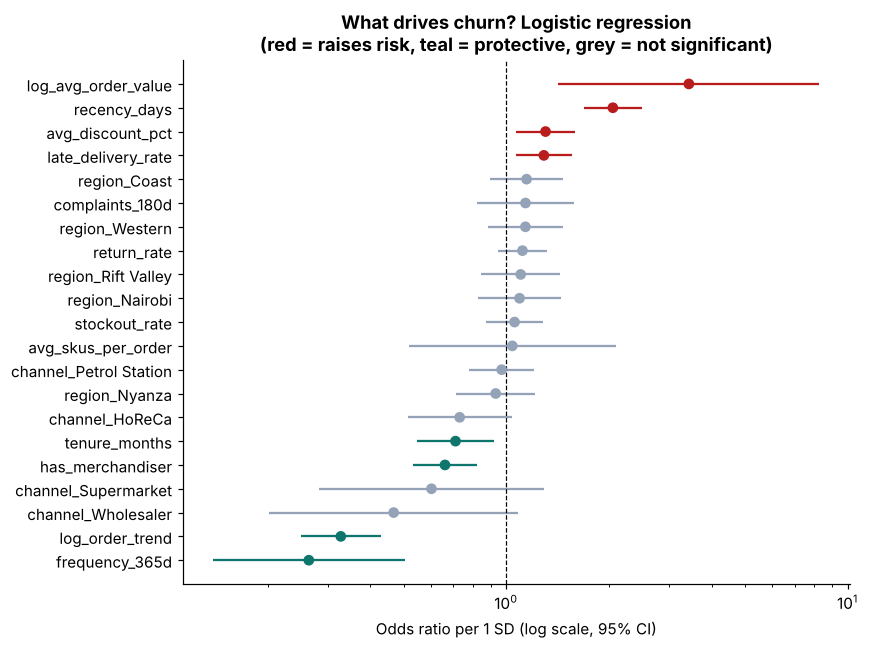

In [15]:
o = ors.sort_values("odds_ratio")
fig, ax = plt.subplots(figsize=(8, 6))
col = np.where(o.p_value < .05, np.where(o.odds_ratio > 1, RED, TEAL), GREY)
ax.errorbar(o.odds_ratio, range(len(o)), xerr=[o.odds_ratio - o.ci_low, o.ci_high - o.odds_ratio],
            fmt="none", ecolor=col, elinewidth=1.5)
ax.scatter(o.odds_ratio, range(len(o)), color=col, zorder=3)
ax.axvline(1, ls="--", color="black", lw=.8); ax.set_xscale("log")
ax.set_yticks(range(len(o)), o.index)
ax.set(xlabel="Odds ratio per 1 SD (log scale, 95% CI)",
       title="What drives churn? Logistic regression\n(red = raises risk, teal = protective, grey = not significant)")
fig.tight_layout(); fig.savefig(OUT / "05_odds_ratios.png", dpi=150); plt.show()

**Interpretation (each effect holds the other variables constant):**

* **Order frequency** (OR ≈ 0.26 per SD) and **order trend** (OR ≈ 0.33) are the strongest protective factors. Habitual outlets whose ordering is steady or growing rarely leave. Put the other way: *a fading order pattern is the loudest alarm bell.*
* **Recency** raises risk: OR ≈ 2.1 for each SD (about 18 days) of extra silence before the snapshot.
* **Late deliveries** (OR ≈ 1.3) and **discount dependence** (OR ≈ 1.3) raise risk significantly. These are drivers **the business controls.**
* **Merchandiser coverage** (OR ≈ 0.66) and **tenure** (OR ≈ 0.71) protect *even after* controlling for channel and behaviour. This is the evidence for investing in field coverage and for looking after new outlets closely in their first months.
* **Not significant once the above are controlled for:** complaints, stock-outs and returns (they overlap with late deliveries and order volume), and the region and channel dummies. *How* an outlet behaves and is served matters more than *what* or *where* it is.
* **A caution on order value:** `log_avg_order_value` shows OR ≈ 3.4, but with a very wide interval (1.4–8.3). Order value is strongly correlated with channel and frequency, and for a fixed order frequency, bigger average orders can mean fewer, bulkier drops. This is **multicollinearity**: the coefficient is unstable and shouldn't be read as "big orders cause churn". When a business-facing explanation matters, keep a simpler model or check variance-inflation factors.

Odds ratios show **association, not proof of causation**. Still, the controllable drivers line up with clear operational levers.

## 11. Models 2 & 3 — Random forest and gradient boosting

Tree ensembles capture **non-linear effects and interactions** automatically (e.g. late deliveries may hurt dukas more than wholesalers). They often predict better but are harder to explain. We compare all three on the **same held-out test set**:

| Metric | Meaning |
|---|---|
| **ROC-AUC** | Probability that a random churner is scored higher than a random non-churner (0.5 = coin flip, 1 = perfect) |
| **PR-AUC** (average precision) | How precise the model stays as it captures more churners. Informative when churn is rare (baseline = churn rate) |
| **Brier score** | Mean squared error of the probabilities (lower = better calibrated) |

In [16]:
rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, class_weight="balanced_subsample",
                            random_state=0, n_jobs=-1).fit(X[~test], y[~test])
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=.05, max_depth=3, subsample=.8,
                                random_state=0).fit(X[~test], y[~test])
preds = {"Logistic regression": np.asarray(p_lr), "Random forest": rf.predict_proba(X[test])[:, 1],
         "Gradient boosting": gb.predict_proba(X[test])[:, 1]}
metrics = pd.DataFrame({m: {"ROC-AUC": roc_auc_score(y[test], p), "PR-AUC": average_precision_score(y[test], p),
                            "Brier": brier_score_loss(y[test], p)} for m, p in preds.items()}).T
metrics.loc["(baseline: no model)"] = [.5, y[test].mean(), brier_score_loss(y[test], np.full(test.sum(), y[~test].mean()))]
metrics.to_csv(OUT / "model_metrics.csv"); metrics.round(3)

,ROC-AUC,PR-AUC,Brier
Logistic regression,0.908,0.744,0.053
Random forest,0.903,0.747,0.069
Gradient boosting,0.880,0.706,0.057
(baseline: no model),0.500,0.117,0.104


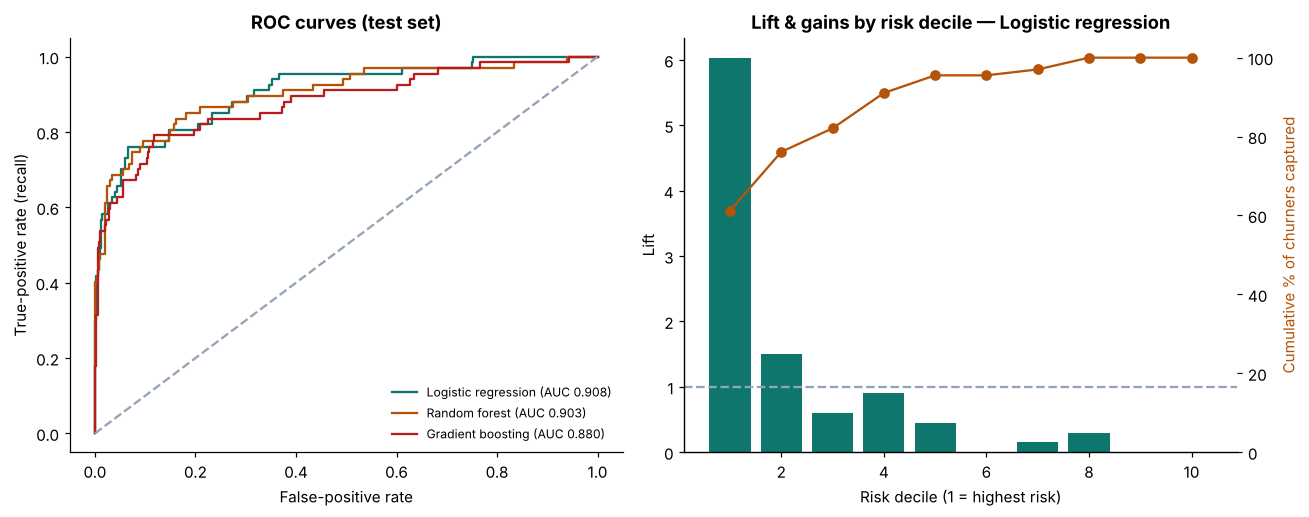

,sum,size,cum_capture,lift
decile,,,,
1,41,58,0.61,6.03
2,10,57,0.76,1.50
3,4,57,0.82,0.60
4,6,57,0.91,0.90
5,3,57,0.96,0.45
6,0,57,0.96,0.00
7,1,57,0.97,0.15
8,2,57,1.00,0.30
9,0,57,1.00,0.00


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
for (m, p), c in zip(preds.items(), [TEAL, AMBER, RED]):
    fpr, tpr, _ = roc_curve(y[test], p)
    ax[0].plot(fpr, tpr, color=c, label=f"{m} (AUC {roc_auc_score(y[test], p):.3f})")
ax[0].plot([0, 1], [0, 1], ls="--", color=GREY); ax[0].legend(frameon=False, fontsize=8)
ax[0].set(title="ROC curves (test set)", xlabel="False-positive rate", ylabel="True-positive rate (recall)")

best_name = metrics.drop("(baseline: no model)")["ROC-AUC"].idxmax()
p_best = preds[best_name]
dec = pd.qcut(pd.Series(p_best).rank(method="first", ascending=False), 10, labels=range(1, 11))
gains = pd.DataFrame({"y": y[test], "decile": dec.values}).groupby("decile", observed=True).y.agg(["sum", "size"])
gains["cum_capture"] = gains["sum"].cumsum() / gains["sum"].sum()
gains["lift"] = (gains["sum"] / gains["size"]) / y[test].mean()
ax[1].bar(gains.index.astype(int), gains.lift, color=TEAL)
ax[1].axhline(1, ls="--", color=GREY)
ax2 = ax[1].twinx(); ax2.plot(gains.index.astype(int), gains.cum_capture * 100, "o-", color=AMBER)
ax2.set_ylabel("Cumulative % of churners captured", color=AMBER); ax2.set_ylim(0, 105)
ax[1].set(title=f"Lift & gains by risk decile — {best_name}", xlabel="Risk decile (1 = highest risk)", ylabel="Lift")
fig.tight_layout(); fig.savefig(OUT / "06_roc_and_gains.png", dpi=150); plt.show()
gains.round(2)

**Interpretation:**

* All three models are **far better than chance** (ROC-AUC 0.88–0.91 against 0.50; PR-AUC about 0.71–0.75 against a 0.12 baseline).
* The **logistic regression is the best model here** (AUC 0.908, best Brier score), slightly ahead of the random forest (0.903) and gradient boosting (0.880). That tells us the drivers act in a fairly **simple, monotonic** way, and we don't have to trade explainability for accuracy. We use it to score outlets in section 13.
* The random forest's Brier score is worse because `class_weight="balanced"` deliberately pushes its probabilities upwards. That's fine for *ranking*, but its scores shouldn't be read as literal probabilities without recalibration.
* The **gains chart** is the business view. The riskiest **10%** of outlets contain about **61%** of all future churners (lift about 6×), and the top **20%** contain about **76%**. A short call list reaches most of the problem.

In [18]:
thr = np.quantile(p_best, .80)                     # act on the top 20% riskiest outlets
pred = (p_best >= thr).astype(int)
cm = pd.DataFrame(confusion_matrix(y[test], pred), index=["Actual: stayed", "Actual: churned"],
                  columns=["Predicted: stay", "Predicted: churn"])
print(f"Threshold = top 20% risk (p >= {thr:.2f}) | precision = {precision_score(y[test], pred):.0%} | "
      f"recall = {recall_score(y[test], pred):.0%}")
cm

Threshold = top 20% risk (p >= 0.12) | precision = 44% | recall = 76%


,Predicted: stay,Predicted: churn
Actual: stayed,441,64
Actual: churned,16,51


**How to read the confusion matrix:** if the team contacts the riskiest 20% of outlets, **precision** is the share of contacted outlets that really were about to churn, and **recall** is the share of all churners the team reached. The threshold is a **business choice**: contact more outlets to catch more churners (higher recall), at the cost of more calls to customers who would have stayed (lower precision). Section 13 picks it on economics instead.

## 12. What drives the tree model? Permutation importance

**Permutation importance** shuffles one feature at a time on the test set and measures how much AUC drops. A large drop means the model relies on that feature. Unlike built-in tree importances, this method isn't biased towards features with many distinct values.

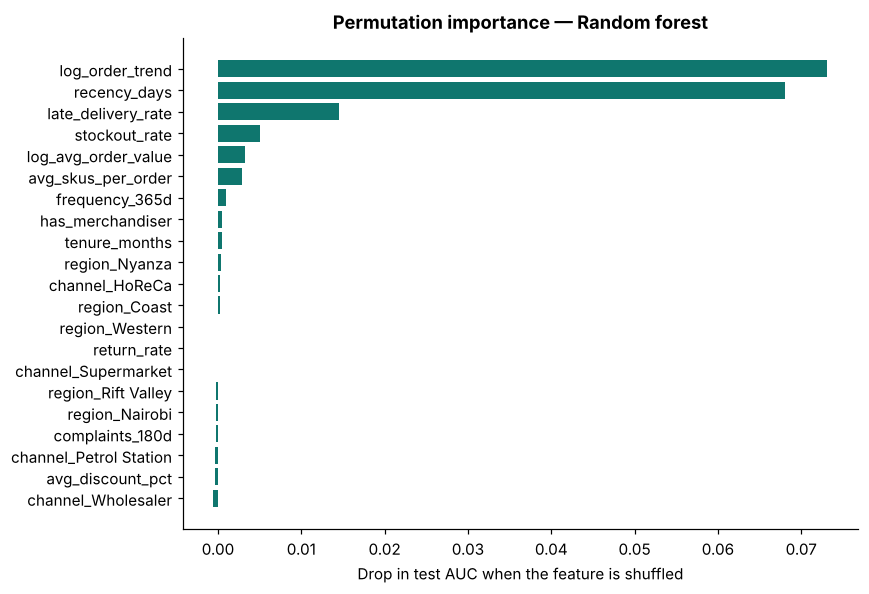

In [19]:
model_for_imp = rf   # tree model: permutation importance shows what a non-linear model relies on
pi = permutation_importance(model_for_imp, X[test], y[test], scoring="roc_auc", n_repeats=15, random_state=0)
imp = pd.Series(pi.importances_mean, X.columns).sort_values()
imp.to_csv(OUT / "permutation_importance.csv")
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(imp.index, imp.values, color=TEAL)
ax.set(xlabel="Drop in test AUC when the feature is shuffled", title="Permutation importance — Random forest")
fig.tight_layout(); fig.savefig(OUT / "07_permutation_importance.png", dpi=150); plt.show()

**Interpretation:** the random forest relies mostly on two **behavioural** signals, **order trend** and **recency**. **Late-delivery rate** is a clear third, the most important *controllable* driver. Everything else adds little once those are known. This matches the logistic regression, and two very different methods agreeing makes the conclusion more trustworthy.

## 13. Bringing it together — churn risk by segment, and the value of acting

We score **every** active outlet with the best model and estimate **revenue at risk** = churn probability × last-12-month revenue. Then we look at it by segment.

In [20]:
best_model = {"Random forest": rf, "Gradient boosting": gb}.get(best_name)
A["churn_prob"] = (best_model.predict_proba(X)[:, 1] if best_model is not None
                   else logit.predict(sm.add_constant(Xs)))
A["revenue_at_risk"] = A.churn_prob * A.monetary_365d
seg_risk = A.groupby("cluster").agg(active_outlets=("customer_id", "size"), actual_churn=("churned", "mean"),
                                    avg_predicted=("churn_prob", "mean"), revenue_at_risk=("revenue_at_risk", "sum"))
seg_risk["share_of_risk"] = seg_risk.revenue_at_risk / seg_risk.revenue_at_risk.sum()
display(seg_risk.sort_values("revenue_at_risk", ascending=False).assign(revenue_at_risk=lambda d: d.revenue_at_risk.map(kes)).round(3))
rfm_risk = A.groupby("rfm_segment").agg(active_outlets=("customer_id", "size"), actual_churn=("churned", "mean"),
                                        revenue_at_risk=("revenue_at_risk", "sum")).reindex(order).dropna()
rfm_risk.assign(revenue_at_risk=rfm_risk.revenue_at_risk.map(kes)).round(3)

,active_outlets,actual_churn,avg_predicted,revenue_at_risk,share_of_risk
cluster,,,,,
Lapsing Key Accounts,35,0.914,0.734,KES 200.0m,0.531
Key Accounts,650,0.026,0.030,KES 101.1m,0.269
Core Small Outlets,1503,0.077,0.074,KES 50.8m,0.135
Lapsed Small Outlets,134,0.657,0.686,KES 24.6m,0.065


,active_outlets,actual_churn,revenue_at_risk
rfm_segment,,,
Champions,948,0.017,KES 70.6m
Loyal,540,0.059,KES 59.5m
Promising / New,245,0.045,KES 2.0m
Needs Attention,240,0.088,KES 3.1m
At Risk,46,0.413,KES 10.0m
Can't Lose Them,77,0.727,KES 218.3m
Hibernating / Lost,226,0.429,KES 13.1m


**Interpretation:** churn *rates* and churn *value* point to different places.

* **Lapsing Key Accounts** that were still active at the snapshot are only **35 outlets**, but more than 90% of them churned, and they hold about **53% of all revenue at risk**. These 35 phone calls matter more than everything else on the list.
* **Key Accounts** have the *lowest* churn rate (about 3%), yet because each one is so valuable they still carry about **27%** of revenue at risk.
* **Core Small Outlets** churn at about 8%, roughly three times the Key Account rate, but each is worth so little that together they hold only about 14% of the value at risk.
* The same story shows in RFM: **Can't Lose Them** outlets churn at about 73% and hold the largest single share of revenue at risk.

That's why a retention programme should rank outlets by **expected value lost**, not by churn probability alone.

### Retention campaign economics

Assume a retention action (rep visit, service recovery, tailored offer) costs **KES 1,500 per outlet** and **saves 25%** of the churners it reaches, keeping a quarter of their annual revenue as gross margin at **20%**. These are illustrative planning assumptions that a pilot would replace. We rank outlets by expected value at risk and ask: *how deep down the list should we go?*

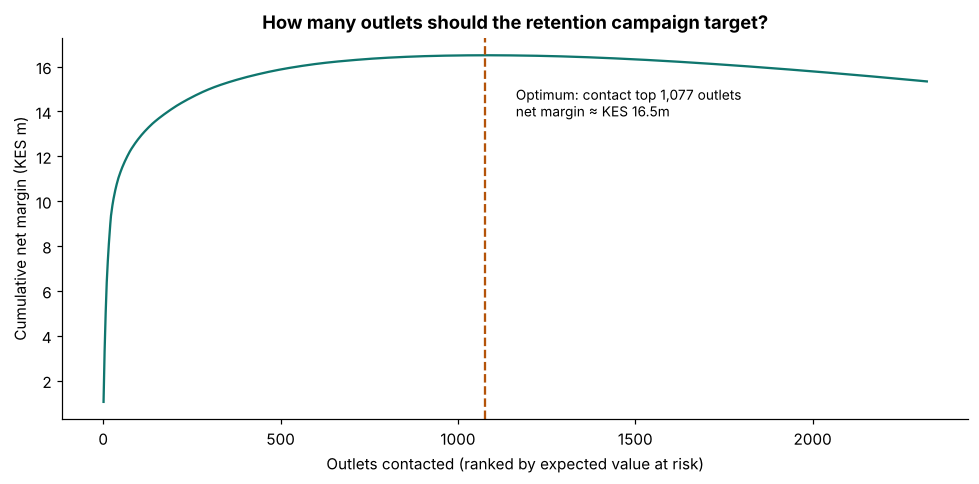

Target 1,077 of 2,322 active outlets (46%) | they hold 96% of revenue at risk | net margin ≈ KES 16.5m


,targeted outlets
cluster,
Key Accounts,515
Core Small Outlets,419
Lapsed Small Outlets,108
Lapsing Key Accounts,35


In [21]:
COST, SAVE_RATE, MARGIN = 1_500, .25, .20
camp = A.sort_values("revenue_at_risk", ascending=False).reset_index(drop=True)
camp["benefit"] = camp.churn_prob * SAVE_RATE * camp.monetary_365d * MARGIN
camp["net_cum"] = (camp.benefit - COST).cumsum()
best_n = int(camp.net_cum.idxmax()) + 1
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.arange(1, len(camp) + 1), camp.net_cum / 1e6, color=TEAL)
ax.axvline(best_n, ls="--", color=AMBER)
ax.annotate(f"Optimum: contact top {best_n:,} outlets\nnet margin ≈ KES {camp.net_cum.max()/1e6:,.1f}m",
            (best_n, camp.net_cum.max() / 1e6), xytext=(20, -40), textcoords="offset points", fontsize=9)
ax.set(xlabel="Outlets contacted (ranked by expected value at risk)", ylabel="Cumulative net margin (KES m)",
       title="How many outlets should the retention campaign target?")
fig.tight_layout(); fig.savefig(OUT / "08_campaign_economics.png", dpi=150); plt.show()
targets = camp.head(best_n)
print(f"Target {best_n:,} of {len(camp):,} active outlets ({best_n/len(camp):.0%}) | "
      f"they hold {targets.revenue_at_risk.sum()/camp.revenue_at_risk.sum():.0%} of revenue at risk | "
      f"net margin ≈ KES {camp.net_cum.max()/1e6:,.1f}m")
targets.cluster.value_counts().rename("targeted outlets").to_frame()

In [22]:
export_cols = ["customer_id", "channel", "region", "rfm_segment", "cluster", "recency_days", "frequency_365d",
               "monetary_365d", "order_trend", "late_delivery_rate", "complaints_180d", "churn_prob", "revenue_at_risk"]
camp[export_cols].assign(in_campaign=lambda d: d.index < best_n).round(4).to_csv(OUT / "churn_risk_scores.csv", index=False)
S[["customer_id", "channel", "region", "R", "F", "M", "rfm_segment", "cluster"]].to_csv(OUT / "customer_segments.csv", index=False)
print("Saved: churn_risk_scores.csv (the call list), customer_segments.csv")

Saved: churn_risk_scores.csv (the call list), customer_segments.csv


**Interpretation:** the net-value curve rises steeply at first, because the first outlets on the list are high-value and high-risk. It then flattens, and eventually falls once the expected saving per outlet drops below the cost of the contact.

* Value at risk is **highly concentrated**: the top **50 outlets** hold about **61%** of it, the top **100** about **69%** and the top **200** about **77%**.
* Under these assumptions the mathematical optimum is about **1,080 outlets** (46% of active outlets, 96% of value at risk). A contact costs little compared with the margin of a Key Account, so it even pays to touch low-risk big customers.
* In practice, capacity decides: **start with the top 100–200** using personal visits (the bulk of the value), and cover the rest of the optimal list with cheap channels (calls, SMS).

The exported **`churn_risk_scores.csv`** is that ranked call list, with each outlet's warning signals (trend, recency, late deliveries).

---

## 14. Recommended actions

| Segment / signal | Action | Owner |
|---|---|---|
| **Key Accounts** | Protect: KAM coverage, delivery SLAs, monthly business reviews; alert on any drop in order trend | Key Account Managers |
| **Lapsing Key Accounts** | Win back within 2 weeks: senior visit, root-cause the service failure, tailored terms | Regional Sales Managers |
| **Core Small Outlets** | Grow efficiently: van-sales routes, range-extension bundles, merchandiser coverage where it pays | Field sales / route-to-market |
| **Lapsed Small Outlets** | Low-cost reactivation: SMS / telesales offers, then reassign to wholesalers if they don't respond | Telesales |
| **Fading order trend** (any segment) | Automatic early-warning alert in the field-force app when the 90-day trend drops below 0.6 | Analytics + Sales Ops |
| **Late deliveries & complaints** | Fix the controllable drivers: delivery-slot reliability, stock-out prevention, complaint closure SLAs | Supply chain & Customer Service |

## 15. Where segmentation and churn analysis are used

| Industry | Segmentation use | Churn use |
|---|---|---|
| **FMCG / distribution** | Outlet tiering, route-to-market design, service models | Outlet attrition early warning, field visit prioritisation |
| **Retail & e-commerce** | Loyalty tiers, personalised offers, RFM email targeting | Lapsed-shopper reactivation |
| **Banking & micro-finance** | Customer value tiers, product needs | Account closure, dormant accounts, loan-customer attrition |
| **Telecoms & mobile money** | Usage-based bundles | Subscriber churn: the classic churn-modelling use case |
| **Insurance** | Risk and value segments | Policy lapse / non-renewal prediction |
| **SaaS & subscriptions** | Usage personas | Cancellation prediction, health scores |
| **Healthcare & NGOs** | Patient / beneficiary profiles | Treatment drop-out and loss-to-follow-up (e.g. TB, HIV programmes) |
| **Utilities & energy** | Consumption profiles | Pay-as-you-go solar customer default / disengagement |

## 16. Limitations and next steps

* **Synthetic data:** effect sizes are illustrative. On real data, validate on a later snapshot (out-of-time test), not just a random split.
* **Correlation, not causation:** test retention actions with a **randomised control group** (uplift modelling) so you measure *saved* churners, not just *predicted* ones.
* **Partial churn:** B2B customers often shift *some* volume to competitors before leaving. Model share-of-wallet decline as well as full churn.
* **Survival analysis** (Cox models) would estimate *when* churn happens, not just *whether*.
* **Monitoring:** recalibrate monthly and track AUC and precision on the latest cohort. Behaviour drifts with seasons and competitor activity.